# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

SUKCES! Wykres został wygenerowany i zapisany w pliku: wykres_zadanie1.png
Poszukaj go w folderze po lewej stronie w VS Code.
Obliczone 'a' aproksymacji liniowej: 2.0414 (oryginał: 2.0)
Obliczone 'b' aproksymacji liniowej: 7.4078 (oryginał: 10.0)


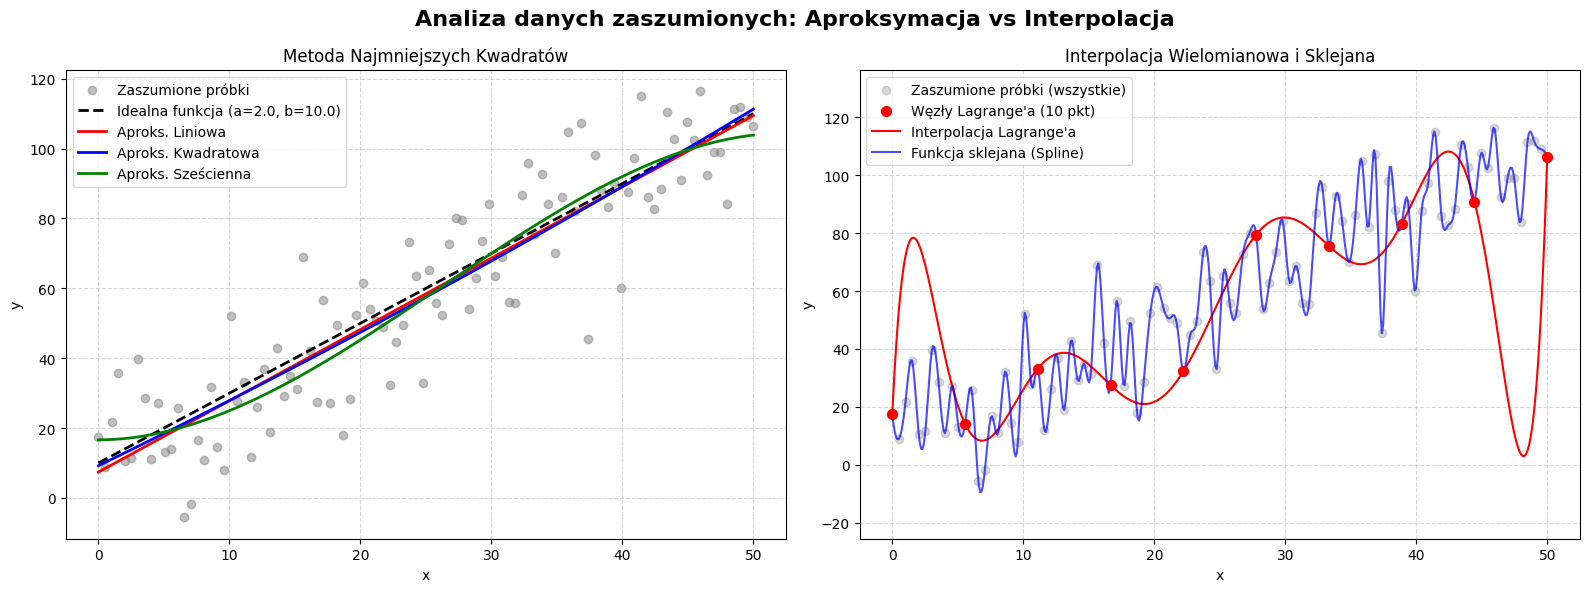

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, interp1d
import warnings


warnings.filterwarnings('ignore')


def true_function(x, a, b):
    return a * x + b

a_true = 2.0
b_true = 10.0


X = np.linspace(0, 50, 100)
Y_true = true_function(X, a_true, b_true)


np.random.seed(42) 
noise = np.random.normal(0, 15, size=100)
Y_noisy = Y_true + noise


def linear_model(x, a, b):
    return a * x + b

def quad_model(x, a, b, c):
    return a * x**2 + b * x + c

def cubic_model(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d


popt_lin, _  = curve_fit(linear_model, X, Y_noisy)
popt_quad, _ = curve_fit(quad_model, X, Y_noisy)
popt_cub, _  = curve_fit(cubic_model, X, Y_noisy)


idx = np.linspace(0, 99, 10, dtype=int)
X_sub = X[idx]
Y_sub = Y_noisy[idx]

poly_lagrange = lagrange(X_sub, Y_sub)


spline_interp = interp1d(X, Y_noisy, kind='cubic', fill_value="extrapolate")


X_dense = np.linspace(0, 50, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analiza danych zaszumionych: Aproksymacja vs Interpolacja', fontsize=16, fontweight='bold')


ax1.scatter(X, Y_noisy, color='gray', alpha=0.5, label='Zaszumione próbki')
ax1.plot(X, Y_true, 'k--', linewidth=2, label=f'Idealna funkcja (a={a_true}, b={b_true})')
ax1.plot(X_dense, linear_model(X_dense, *popt_lin), 'r-', linewidth=2, label='Aproks. Liniowa')
ax1.plot(X_dense, quad_model(X_dense, *popt_quad), 'b-', linewidth=2, label='Aproks. Kwadratowa')
ax1.plot(X_dense, cubic_model(X_dense, *popt_cub), 'g-', linewidth=2, label='Aproks. Sześcienna')

ax1.set_title('Metoda Najmniejszych Kwadratów')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)


ax2.scatter(X, Y_noisy, color='gray', alpha=0.3, label='Zaszumione próbki (wszystkie)')
ax2.scatter(X_sub, Y_sub, color='red', zorder=5, s=50, label='Węzły Lagrange\'a (10 pkt)')
ax2.plot(X_dense, poly_lagrange(X_dense), 'r-', linewidth=1.5, label='Interpolacja Lagrange\'a')
ax2.plot(X_dense, spline_interp(X_dense), 'b-', alpha=0.7, linewidth=1.5, label='Funkcja sklejana (Spline)')

ax2.set_title('Interpolacja Wielomianowa i Sklejana')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_ylim(min(Y_noisy) - 20, max(Y_noisy) + 20) 
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()


nazwa_pliku = 'wykres_zadanie1.png'
plt.savefig(nazwa_pliku, dpi=300)

print("="*50)
print(f"SUKCES! Wykres został wygenerowany i zapisany w pliku: {nazwa_pliku}")
print("Poszukaj go w folderze po lewej stronie w VS Code.")
print("="*50)
print(f"Obliczone 'a' aproksymacji liniowej: {popt_lin[0]:.4f} (oryginał: {a_true})")
print(f"Obliczone 'b' aproksymacji liniowej: {popt_lin[1]:.4f} (oryginał: {b_true})")

***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).